<a href="https://colab.research.google.com/github/Marcel-12345/PCVK_Ganjil_2026/blob/main/Week6_244107020141.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anselmus Marcel Putra Andria 244107020141
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
D. PRAKTIKUM FILTER


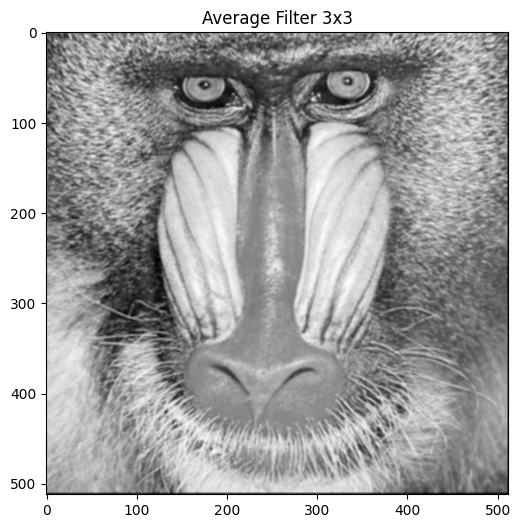

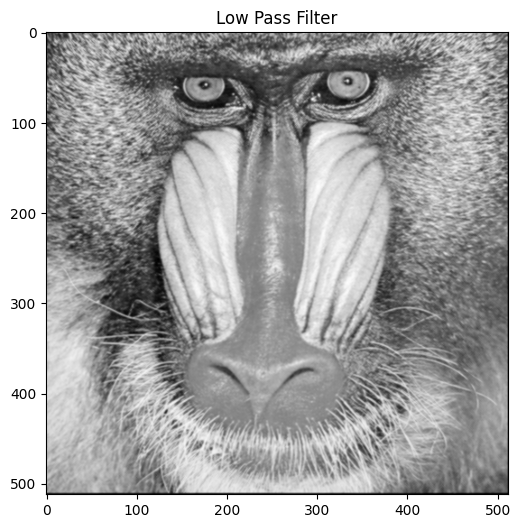

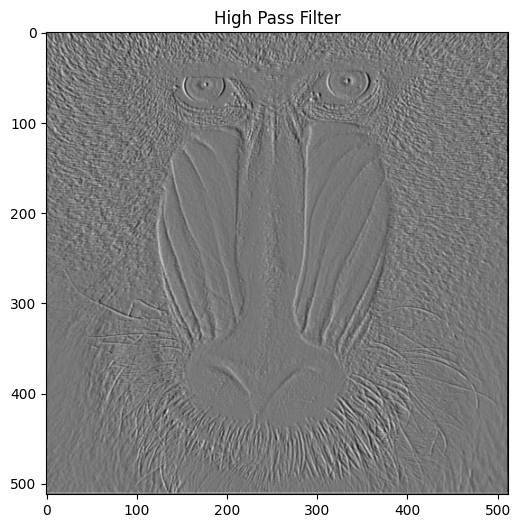

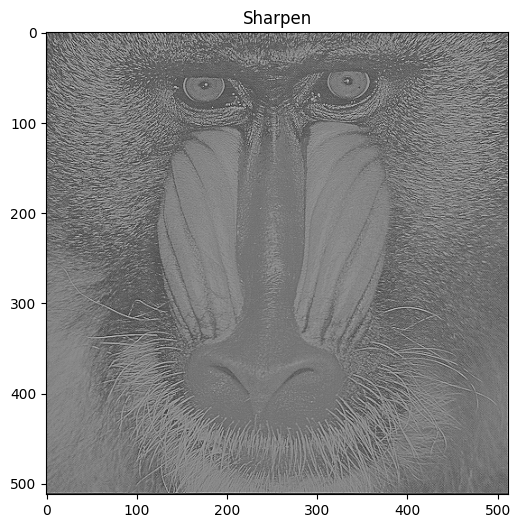

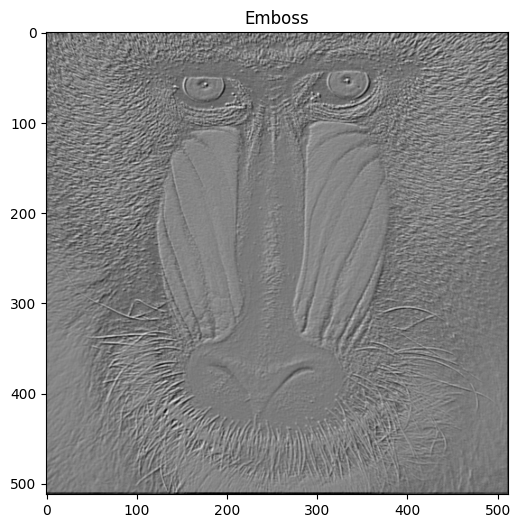

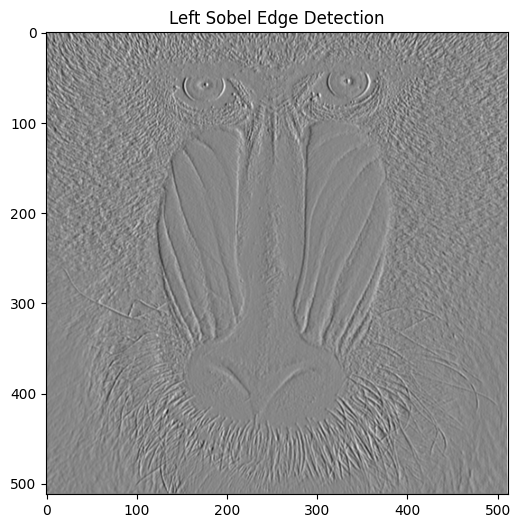

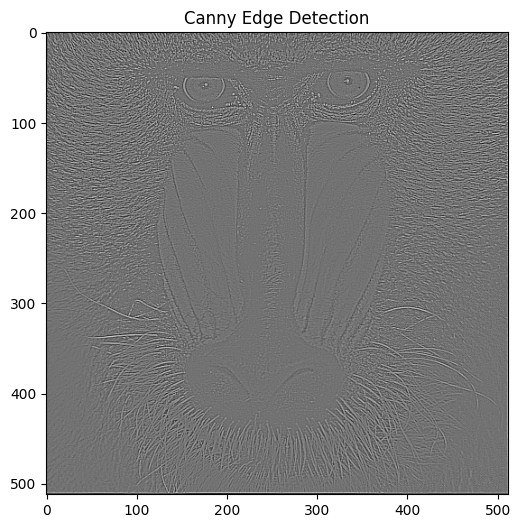

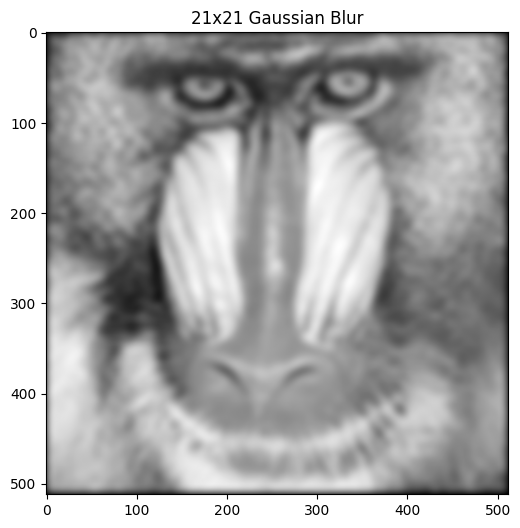

E. FILTER LIBRARY DAN FILTER MODERN 
Percobaan 1


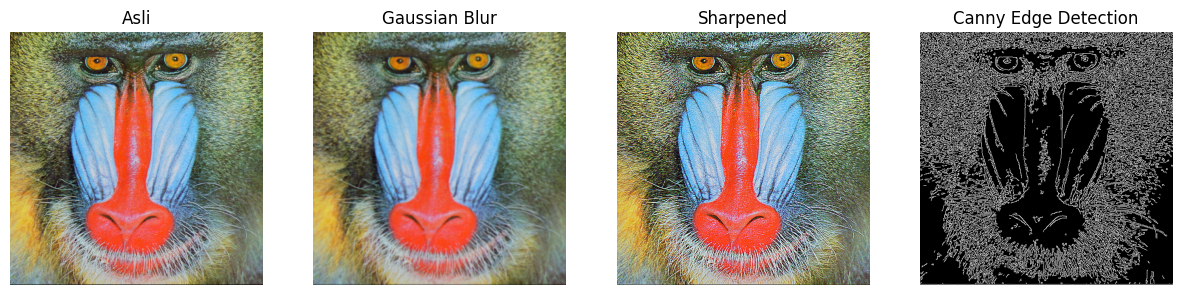

Percobaan 2


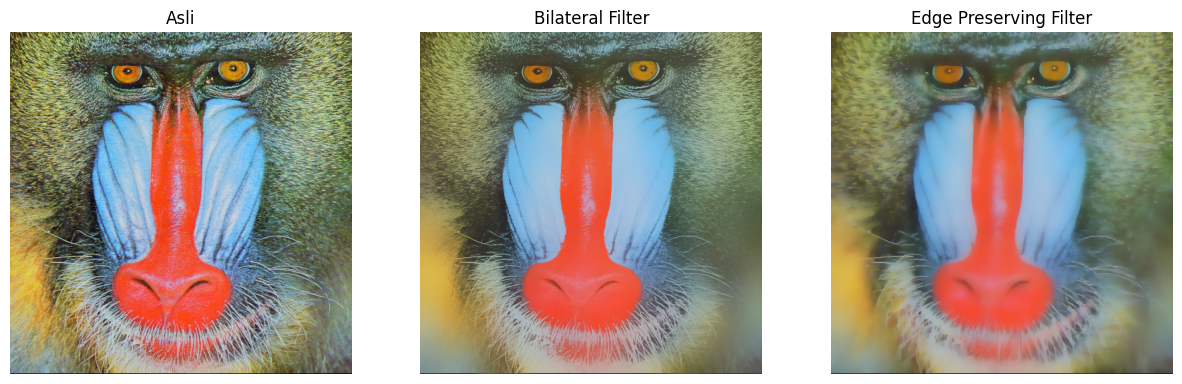

Percobaan 3


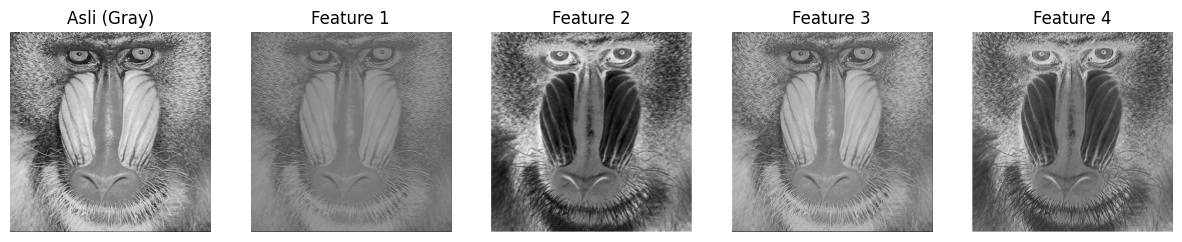

Percobaan 4


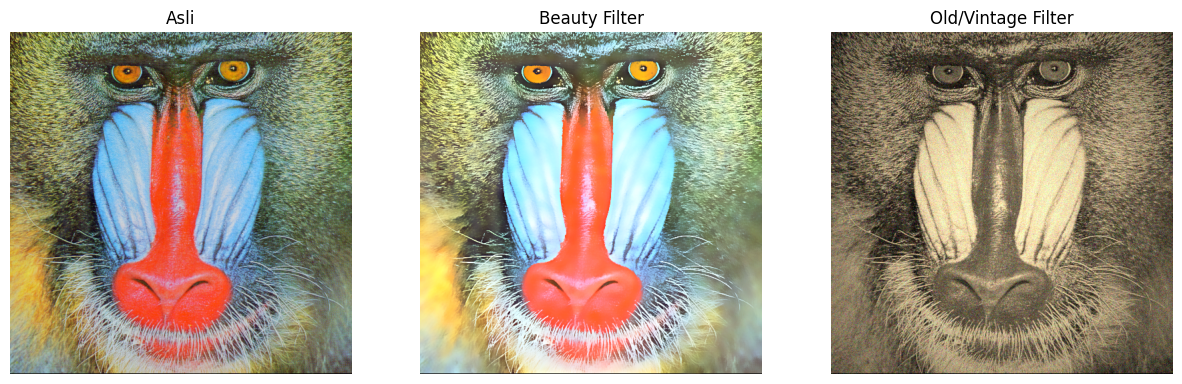

Percobaan 5


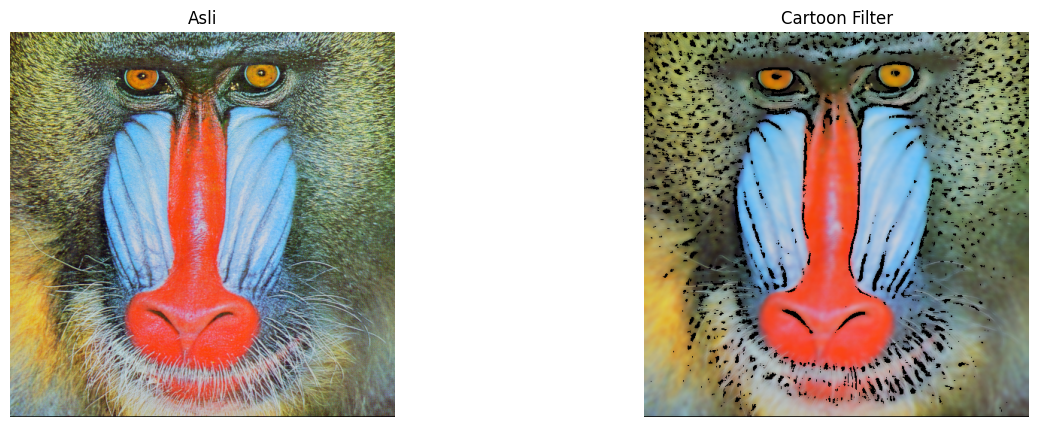

Percobaan 6


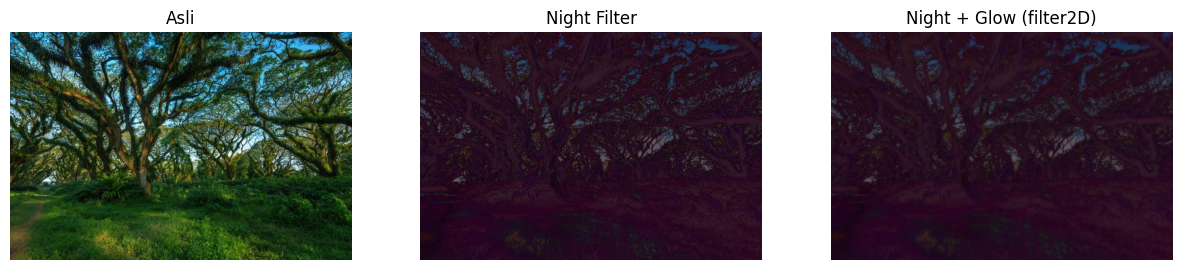

Percobaan 7


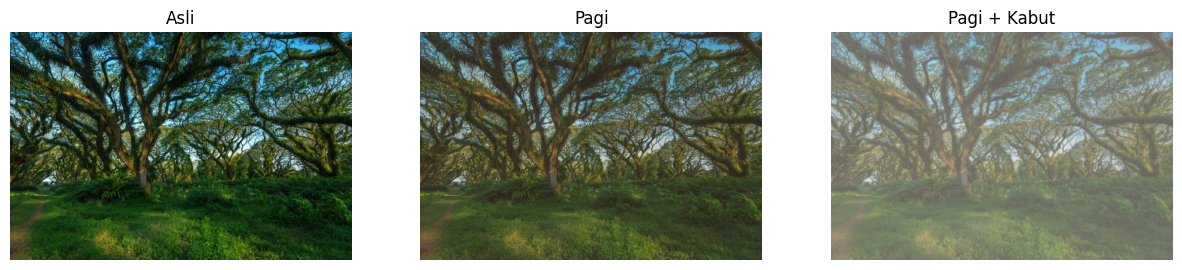

Tugas Praktikum
--- TUGAS 1: PERBANDINGAN MEAN FILTER VS MEDIAN FILTER ---


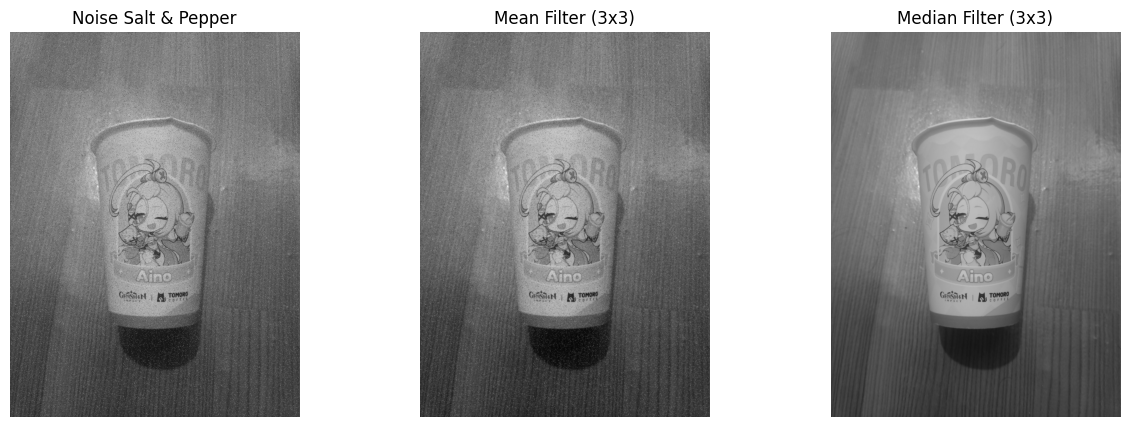


--- TUGAS 2: PEMILIHAN UKURAN KERNEL SHARPENING ---


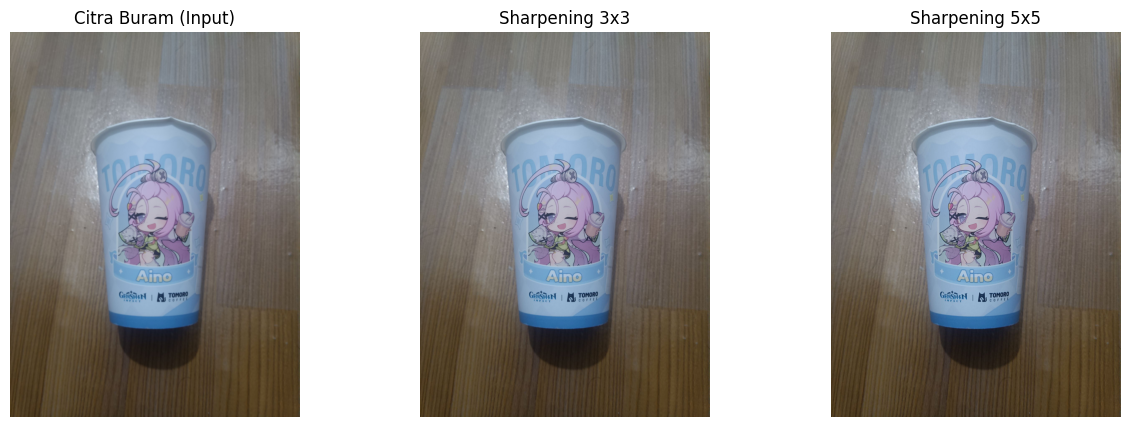


--- TUGAS 3: FILTER KARTUN SEDERHANA ---


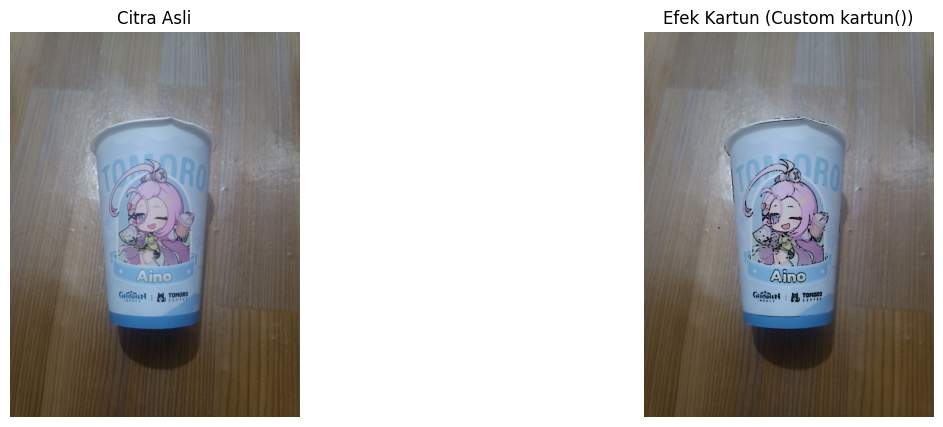

In [2]:
NAMA = 'Anselmus Marcel Putra Andria'
NIM  = '244107020141'
print(NAMA, NIM)

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im
import torch
import torch.nn as nn

# D. PRAKTIKUM FILTER
print("D. PRAKTIKUM FILTER")

# -------------------------------------------------------------------
# 1. Definisi Fungsi Konvolusi 2D Manual (tanpa cv.filter2D)
# -------------------------------------------------------------------
def convolution2d(image, kernel, stride=1, padding=0):
    # Menambahkan padding jika nilai padding > 0
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Menghitung ukuran citra keluaran
    out_h = int((img_h - kernel_h) / stride) + 1
    out_w = int((img_w - kernel_w) / stride) + 1

    output = np.zeros((out_h, out_w))

    # Proses konvolusi
    for y in range(0, out_h):
        for x in range(0, out_w):
            sub_img = image[y*stride : y*stride + kernel_h, x*stride : x*stride + kernel_w]
            output[y, x] = np.sum(sub_img * kernel)

    return output

# -------------------------------------------------------------------
# 2. Load Citra Masukan dan Ubah ke Grayscale
# -------------------------------------------------------------------
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020141/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# -------------------------------------------------------------------
# 3. Definisi Seluruh Kernel Filter (Sesuai Soal D.3)
# -------------------------------------------------------------------
# a. Average Filter (3x3)
kernel_avg = (1.0 / 9.0) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

# b. Low Pass Filter (3x3)
kernel_lpf = (1.0 / 12.0) * np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
])

# c. High Pass Filter (3x3)
kernel_hpf = np.array([
    [-1,  0, 1],
    [-1,  0, 3],
    [-3,  0, 1]
])

# d. Sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# e. Emboss
kernel_emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
])

# f. Left Sobel Edge Detection
kernel_left_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

# g. Canny Edge Detection (Kernel Laplasian / Edge Detection)
kernel_canny_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# h. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

# -------------------------------------------------------------------
# 4. Melakukan Konvolusi Menggunakan Fungsi convolution2d
# -------------------------------------------------------------------
res_avg        = convolution2d(img_gray, kernel_avg, stride=1, padding=1)
res_lpf        = convolution2d(img_gray, kernel_lpf, stride=1, padding=1)
res_hpf        = convolution2d(img_gray, kernel_hpf, stride=1, padding=1)
res_sharpen    = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss     = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny_edge = convolution2d(img_gray, kernel_canny_edge, stride=1, padding=1)
res_gauss_21   = convolution2d(img_gray, kernel_gaussian_21x21, stride=1, padding=10)

# -------------------------------------------------------------------
# 5. Menampilkan Hasil Konvolusi
# -------------------------------------------------------------------
filters = [
    ("Average Filter 3x3", res_avg),
    ("Low Pass Filter", res_lpf),
    ("High Pass Filter", res_hpf),
    ("Sharpen", res_sharpen),
    ("Emboss", res_emboss),
    ("Left Sobel Edge Detection", res_left_sobel),
    ("Canny Edge Detection", res_canny_edge),
    ("21x21 Gaussian Blur", res_gauss_21)
]

for title, res in filters:
    plt.figure(figsize=(6, 6))
    plt.imshow(res, cmap='gray')
    plt.title(title)
    plt.axis('on')
    plt.show()

# E. FILTER LIBRARY DAN FILTER MODERN
print("E. FILTER LIBRARY DAN FILTER MODERN ")

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Percobaan 1
print("Percobaan 1")

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

# Percobaan 2
print("Percobaan 2")

# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

# Percobaan 3
print("Percobaan 3")

# Filter Feature Map yang digunakan pada CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

# Percobaan 4
print("Percobaan 4")

# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

# Percobaan 5
print("Percobaan 5")

# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

# Percobaan 6
print("Percobaan 6")

# Night Filter
img_night = cv.imread("/content/drive/MyDrive/PCVK/Images/244107020141/djawatan.jpg")
img_night_gray = cv.cvtColor(img_night, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_night, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_night, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

# Percobaan 7
print("Percobaan 7")

# Filter Suasana Pagi dan Kabut
# ============================
# Step 1: Kurangi kontras & cerahkan
# ============================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img_night, alpha=alpha, beta=beta)

# ============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_night, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

# Tugas Praktikum
print("Tugas Praktikum")

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# Fungsi Pembantu untuk Menampilkan Gambar Berdampingan
# =====================================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        if len(img.shape) == 2:  # Grayscale
            plt.imshow(img, cmap="gray")
        else:  # Color (RGB)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load Gambar Sampel
# Sesuaikan path gambar dengan gambar yang Anda miliki di Google Drive
img_path = "/content/drive/MyDrive/PCVK/Images/244107020141/obj1.jpg"
img_color = cv.imread(img_path)

if img_color is None:
    # Menggunakan gambar dummy jika gambar dari drive belum ter-load
    img_color = np.zeros((300, 300, 3), dtype=np.uint8)
    cv.circle(img_color, (150, 150), 80, (255, 200, 150), -1)

img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)


# =====================================================================
# 1. TUGAS ANALISIS: Mean Filter vs. Median Filter (Salt & Pepper)
# =====================================================================
print("--- TUGAS 1: PERBANDINGAN MEAN FILTER VS MEDIAN FILTER ---")

# a. Tambahkan Noise Salt and Pepper
def add_salt_and_pepper_noise(image, amount=0.04):
    noisy_img = np.copy(image)
    # Noise Salt (Putih)
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255

    # Noise Pepper (Hitam)
    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0
    return noisy_img

noisy_gray = add_salt_and_pepper_noise(img_gray, amount=0.05)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy_gray, (3, 3))
median_filtered = cv.medianBlur(noisy_gray, 3)

# Tampilkan Hasil
show_side_by_side(
    [noisy_gray, mean_filtered, median_filtered],
    ["Noise Salt & Pepper", "Mean Filter (3x3)", "Median Filter (3x3)"]
)

# c. Analisis Visual:
# (Lihat di bawah)


# =====================================================================
# 2. TUGAS EVALUASI: Pemilihan Ukuran Kernel Sharpening (3x3 vs 5x5)
# =====================================================================
print("\n--- TUGAS 2: PEMILIHAN UKURAN KERNEL SHARPENING ---")

# Buat citra sedikit buram terlebih dahulu
blurry_img = cv.GaussianBlur(img_color, (5, 5), 0)

# a. Buat Kernel Penajaman 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Kernel 5x5 Unsharp Masking / Laplasian Sharpening
kernel_sharpen_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  8,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1]
]) / 8.0

# b. Terapkan Filter
sharpened_3x3 = cv.filter2D(blurry_img, -1, kernel_sharpen_3x3)
sharpened_5x5 = cv.filter2D(blurry_img, -1, kernel_sharpen_5x5)

# Tampilkan Hasil
show_side_by_side(
    [blurry_img, sharpened_3x3, sharpened_5x5],
    ["Citra Buram (Input)", "Sharpening 3x3", "Sharpening 5x5"]
)

# c. Evaluasi Hasil:
# (lihat di bawah)


# =====================================================================
# 3. TUGAS KREASI: Filter Kartun Sederhana
# =====================================================================
print("\n--- TUGAS 3: FILTER KARTUN SEDERHANA ---")

# a. Fungsi Kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY, 9, 9
    )

    # Ubah edges ke 3-channel agar sejajar dengan gambar berwarna
    edges_colored = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan menggunakan operasi bitwise AND
    cartoon_img = cv.bitwise_and(color_smooth, edges_colored)
    return cartoon_img

# b. Terapkan dan Tampilkan Berdampingan
cartoon_result = kartun(img_color)

show_side_by_side(
    [img_color, cartoon_result],
    ["Citra Asli", "Efek Kartun (Custom kartun())"]
)

#Penjelasan
**Tugas praktikum 1 poin C:**

ANALISIS VISUAL:
- Median Filter jauh lebih bersih karena mengambil nilai MEDIAN (nilai tengah) dari
  piksel tetangga setelah diurutkan. Karena noise Salt & Pepper bernilai ekstrem (0 atau 255),
  nilai ekstrem tersebut berada di ujung urutan dan akan terbuang saat memilih median.
- Mean Filter bekerja dengan merata-ratakan (AVERAGE) semua piksel tetangga. Akibatnya,
  nilai ekstrem dari noise ikut terhitung, menyebabkan bintik noise tidak hilang melainkan
  tersebar menjadi bercak-bercak buram (blur) di seluruh citra.

**Tugas praktikum 2 poin C:**

EVALUASI HASIL:
- Kernel 3x3: Memberikan tingkat penajaman yang seimbang. Tepi objek menjadi lebih tegas
  dan jelas tanpa memunculkan distorsi artefak yang berlebihan.
- Kernel 5x5: Memberikan efek penajaman berlebih (oversharpening/halo effect) serta
  meningkatkan kadar noise secara drastis pada area yang datar.
- Kesimpulan: Kernel 3x3 adalah yang paling optimal untuk digunakan sehari-hari karena
  menjaga keseimbangan antara kejelasan tepi dan kadar noise/distorsi visual.